# 04 — Demand Estimation

Rewritten from scratch against the current proposal (Section 5.1). Builds Bᵢ (base demand),
then the equity-adjusted Dᵢ(α) with total-demand normalisation, for the four α scenarios
A/B/C/D (α = 0, 0.1, 0.3, 0.5).

## 0. Setup and reload cleaned data

In [11]:
import pandas as pd
import numpy as np
import geopandas as gpd
import matplotlib.pyplot as plt
import os

BASE = "/Users/alexia/Documents/CASA/Dissertation"

census_london = pd.read_csv(os.path.join(BASE, "05_processed/census_london_clean.csv"))
imd_london    = pd.read_csv(os.path.join(BASE, "05_processed/imd_london_clean.csv"))
seff_london   = pd.read_csv(os.path.join(BASE, "05_processed/seff_london.csv"))

figures_dir = os.path.join(BASE, "06_outputs/figures")
os.makedirs(figures_dir, exist_ok=True)

print("Datasets reloaded.")
print(f"census_london: {census_london.shape}, imd_london: {imd_london.shape}, seff_london: {seff_london.shape}")

Datasets reloaded.
census_london: (4994, 8), imd_london: (4994, 10), seff_london: (4994, 7)


## 1. Base demand Bᵢ = (Hᵢ × Cᵢ) × Pd × Ppub × Uᵢ

Pd and Ppub are constants identical across all LSOAs — they do not affect spatial ranking,
only the overall scale of Bᵢ. Kept explicit here (rather than dropped) so Bᵢ stays on an
interpretable scale and the calibration source is visible in the code, not just the proposal text.

In [12]:
# Pd: daily BEV charging probability (DfT EV Tracker Y1, national estimate)
Pd = 4.3 / 14

# Ppub: fraction of charges occurring at public locations (DfT EV Tracker Y1 §8.5)
Ppub = 1.8 / 4.4

print(f"Pd   = 4.3 / 14  = {Pd:.6f}")
print(f"Ppub = 1.8 / 4.4 = {Ppub:.6f}")

Pd   = 4.3 / 14  = 0.307143
Ppub = 1.8 / 4.4 = 0.409091


In [13]:
# Uᵢ = 1 + ūᵢ (utilisation-pressure multiplier), with Uᵢ = 1 (neutral) for LSOAs with no
# registered EVSE (has_evse_i = False) — absence of infrastructure is not evidence of
# absence of demand. ūᵢ is NaN for these rows in seff_london (by design, see 03_EDA), so
# the neutral rule is applied explicitly here rather than relying on a silent fillna(0).
demand_base = census_london[["lsoa_code", "lsoa_name", "Hi", "Ci"]].merge(
    seff_london[["lsoa_code", "ej", "seff", "ubar_i", "has_evse_i"]], on="lsoa_code", how="left"
)

demand_base["Ui"] = np.where(demand_base["has_evse_i"], 1 + demand_base["ubar_i"], 1.0)

print("Ui summary:")
print(demand_base["Ui"].describe())
print()
print(f"LSOAs with Ui = 1 exactly (no registered EVSE, neutral treatment): {(demand_base['Ui'] == 1.0).sum()}")
assert demand_base["Ui"].isna().sum() == 0, "Ui should never be NaN — check has_evse_i / ubar_i merge"

Ui summary:
count    4994.000000
mean        1.062798
std         0.136379
min         1.000000
25%         1.000000
50%         1.000010
75%         1.062812
max         1.962401
Name: Ui, dtype: float64

LSOAs with Ui = 1 exactly (no registered EVSE, neutral treatment): 2446


In [14]:
# Bᵢ = (Hᵢ × Cᵢ) × Pd × Ppub × Uᵢ — base demand, before equity weighting
demand_base["Vi"] = demand_base["Hi"] * demand_base["Ci"]           # household vehicle stock
demand_base["Bi"] = demand_base["Vi"] * Pd * Ppub * demand_base["Ui"]

print("=== Bᵢ summary ===")
print(demand_base["Bi"].describe())
print()
print("Vi (household vehicle stock) summary:")
print(demand_base["Vi"].describe())

=== Bᵢ summary ===
count    4994.000000
mean       72.193650
std        27.989898
min         8.669805
25%        49.883287
50%        70.740584
75%        93.106169
max       198.136514
Name: Bi, dtype: float64

Vi (household vehicle stock) summary:
count    4994.000000
mean      545.504005
std       214.164125
min        69.000000
25%       373.000000
50%       535.000000
75%       707.000000
max      1435.000000
Name: Vi, dtype: float64


## 2. Equity-adjusted demand Dᵢ(α), normalised so total demand is constant across scenarios

Because IMDᵢ (income_score) > 0 for every LSOA, raising α mechanically increases total
demand — this would confound equity reallocation with an artificial rise in total demand
when comparing scenarios. Dᵢ(α) = Bᵢ(1+α·IMDᵢ) / norm(α), where
norm(α) = [Σ Bᵢ(1+α·IMDᵢ)] / [Σ Bᵢ], guarantees Σ Dᵢ(α) = Σ Bᵢ for every α (proposal
Section 5.1). At α=0 this reduces exactly to Dᵢ(0) = Bᵢ.

In [15]:
demand_full = demand_base.merge(imd_london[["lsoa_code", "income_score"]], on="lsoa_code", how="left")
assert demand_full["income_score"].isna().sum() == 0, "Every London LSOA should have an income_score"

SCENARIOS = {"A": 0.0, "B": 0.1, "C": 0.3, "D": 0.5}

def demand_for_alpha(Bi, IMDi, alpha):
    raw = Bi * (1 + alpha * IMDi)
    norm_factor = raw.sum() / Bi.sum()
    return raw / norm_factor

Bi = demand_full["Bi"].to_numpy()
IMDi = demand_full["income_score"].to_numpy()

for label, alpha in SCENARIOS.items():
    demand_full[f"D_{label}"] = demand_for_alpha(Bi, IMDi, alpha)

print("=== Total demand by scenario (should all match Σ Bᵢ) ===")
print(f"Sigma Bi:            {demand_full['Bi'].sum():,.2f}")
for label, alpha in SCENARIOS.items():
    total = demand_full[f"D_{label}"].sum()
    bi_total = demand_full["Bi"].sum()
    print(f"Sigma D_{label} (alpha={alpha}): {total:,.2f}  (matches Bi: {np.isclose(total, bi_total)})")

print()
print("alpha=0 (Scenario A) reproduces Bi exactly:", np.allclose(demand_full["D_A"], demand_full["Bi"]))

=== Total demand by scenario (should all match Σ Bᵢ) ===
Sigma Bi:            360,535.09
Sigma D_A (alpha=0.0): 360,535.09  (matches Bi: True)
Sigma D_B (alpha=0.1): 360,535.09  (matches Bi: True)
Sigma D_C (alpha=0.3): 360,535.09  (matches Bi: True)
Sigma D_D (alpha=0.5): 360,535.09  (matches Bi: True)

alpha=0 (Scenario A) reproduces Bi exactly: True


## 3. Distribution comparison across scenarios and save

In [16]:
scenario_cols = [f"D_{label}" for label in ["A", "B", "C", "D"]]
print(demand_full[scenario_cols].describe())

output_path = os.path.join(BASE, "05_processed/demand_london.csv")
demand_full.to_csv(output_path, index=False)
print(f"\nSaved to: {output_path}")

               D_A          D_B          D_C          D_D
count  4994.000000  4994.000000  4994.000000  4994.000000
mean     72.193650    72.193650    72.193650    72.193650
std      27.989898    27.588413    26.926840    26.426815
min       8.669805     8.521826     8.246356     7.995191
25%      49.883287    50.239082    50.763165    51.427486
50%      70.740584    70.999708    71.337186    71.806295
75%      93.106169    92.805042    92.195158    91.699744
max     198.136514   194.348638   187.297321   189.693545

Saved to: /Users/alexia/Documents/CASA/Dissertation/05_processed/demand_london.csv


## 4. Sanity check: does higher α shift demand toward more deprived LSOAs?

Expect the correlation between Dᵢ(α) and income_score to strengthen (become more positive)
as α increases from A (0) to D (0.5) — this is the equity mechanism working as intended.

In [17]:
from scipy.stats import pearsonr

print("=== Pearson r: D_scenario vs income_score ===")
for label, alpha in SCENARIOS.items():
    r, p = pearsonr(demand_full[f"D_{label}"], demand_full["income_score"])
    print(f"Scenario {label} (alpha={alpha}): r = {r:.4f}, p = {p:.4g}")

=== Pearson r: D_scenario vs income_score ===
Scenario A (alpha=0.0): r = -0.4017, p = 5.354e-193
Scenario B (alpha=0.1): r = -0.3734, p = 4.723e-165
Scenario C (alpha=0.3): r = -0.3176, p = 1.85e-117
Scenario D (alpha=0.5): r = -0.2633, p = 5.832e-80


## 5. Demand maps — Scenario A (baseline) vs Scenario C (primary)

In [18]:
# Reload LSOA boundaries for mapping (not persisted from 03_EDA — kept modular so each
# notebook reloads what it needs)
lsoa_boundaries = gpd.read_file(os.path.join(BASE, "03_data/demand/spatial/LSOA_2021_EW_BGC_V5.shp"))
if lsoa_boundaries.crs is None or lsoa_boundaries.crs.to_epsg() != 27700:
    lsoa_boundaries = lsoa_boundaries.to_crs(epsg=27700)

london_codes = set(census_london["lsoa_code"])
lsoa_london = lsoa_boundaries[lsoa_boundaries["LSOA21CD"].isin(london_codes)].copy()
lsoa_london = lsoa_london.rename(columns={"LSOA21CD": "lsoa_code"})[["lsoa_code", "geometry"]]

print(f"LSOA boundaries matched: {len(lsoa_london)} / {len(london_codes)} expected")

LSOA boundaries matched: 4994 / 4994 expected


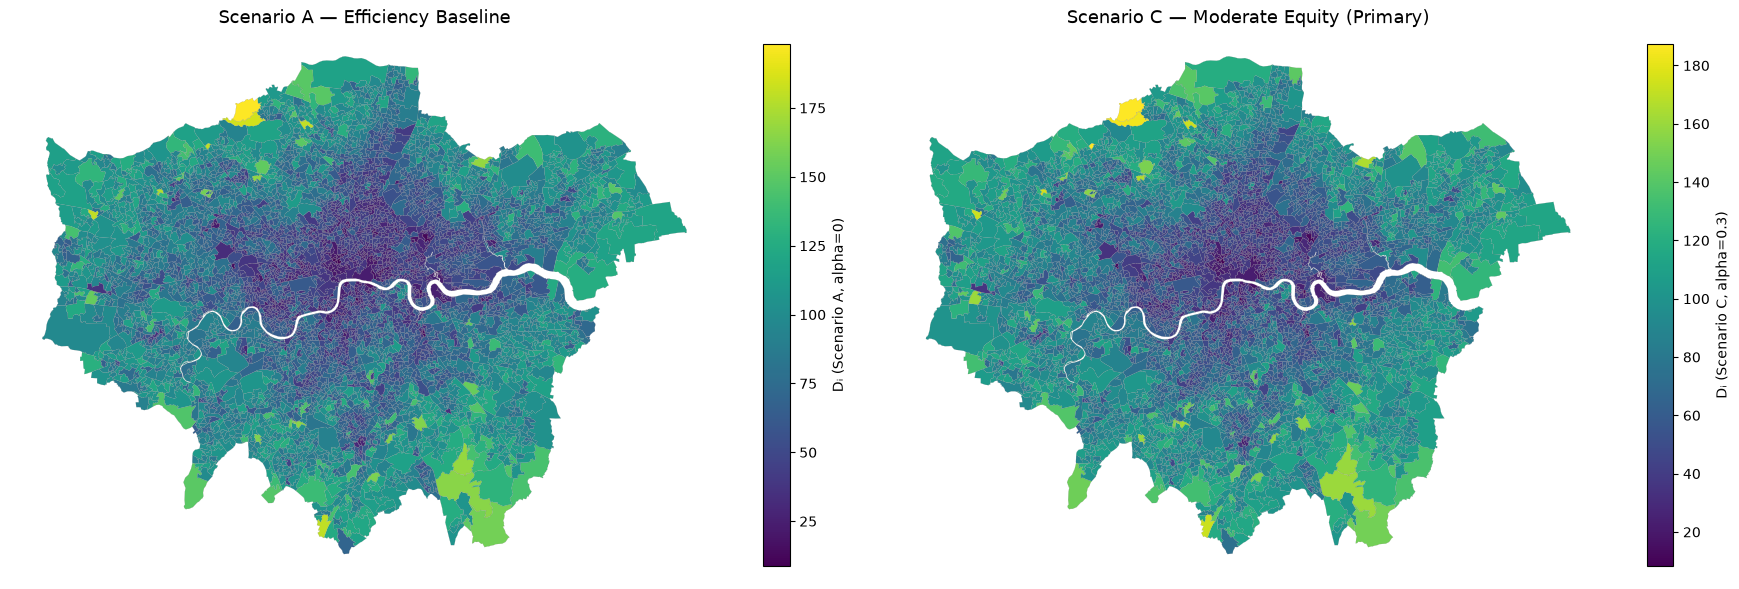

Saved: fig_demand_scenarios_A_C.png


In [19]:
demand_map = lsoa_london.merge(demand_full[["lsoa_code", "D_A", "D_C"]], on="lsoa_code", how="left")

fig, axes = plt.subplots(1, 2, figsize=(18, 9))
demand_map.plot(column="D_A", cmap="viridis", linewidth=0.1, edgecolor="grey",
                 legend=True, ax=axes[0], legend_kwds={"label": "Dᵢ (Scenario A, alpha=0)", "shrink": 0.6})
axes[0].set_title("Scenario A — Efficiency Baseline", fontsize=13); axes[0].axis("off")

demand_map.plot(column="D_C", cmap="viridis", linewidth=0.1, edgecolor="grey",
                 legend=True, ax=axes[1], legend_kwds={"label": "Dᵢ (Scenario C, alpha=0.3)", "shrink": 0.6})
axes[1].set_title("Scenario C — Moderate Equity (Primary)", fontsize=13); axes[1].axis("off")

plt.tight_layout()
plt.savefig(os.path.join(figures_dir, "fig_demand_scenarios_A_C.png"), dpi=300, bbox_inches="tight")
plt.show()
print("Saved: fig_demand_scenarios_A_C.png")

## 6. Update pipeline_summary.csv

In [20]:
pipeline_summary = pd.read_csv(os.path.join(BASE, "05_processed/pipeline_summary.csv"))

updates = {
    "Demand Di computed (4 scenarios A-D)": f"Done — {len(demand_full)} LSOAs, total demand = {demand_full['Bi'].sum():,.1f}",
}
for item, value in updates.items():
    if (pipeline_summary["Item"] == item).any():
        pipeline_summary.loc[pipeline_summary["Item"] == item, "Count"] = value
    else:
        pipeline_summary = pd.concat([pipeline_summary, pd.DataFrame([{"Item": item, "Count": value}])], ignore_index=True)

pipeline_summary.to_csv(os.path.join(BASE, "05_processed/pipeline_summary.csv"), index=False)
print(pipeline_summary.to_string(index=False))

                                             Item                                       Count
                    LSOAs loaded (Greater London)                                        4994
Household total (Hi sum, validated vs gor:London)                                     3423845
      On-street EVSE locations (OpenStreetEV_GLA)                                       21366
    Session records (join_august2025, post-clean)                                       63105
     Unique EVSEs with ≥1 session (ur_j computed)                                       10465
           EVSEs matched to LSOA via spatial join                                       38375
        eⱼ / Sᵢᵉᶠᶠ / Uᵢ / has_evse_i (LSOA-level)      Done — 3493 LSOAs with has_evse_i=True
             Demand Di computed (4 scenarios A-D) Done — 4994 LSOAs, total demand = 360,535.1
